In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Load CSV File

In [2]:
df = pd.read_csv("bhatbhateni.csv")

In [3]:
df.head()

,Year,Month,Branch,Product,Units_Sold,Unit_Price_NPR,Revenue_NPR
0,2025,Jan,Koteshwor,Laptop,220,90000,19800000
1,2025,Feb,Koteshwor,Laptop,214,90000,19260000
2,2025,Mar,Koteshwor,Laptop,260,90000,23400000
3,2025,Apr,Koteshwor,Laptop,230,90000,20700000
4,2025,May,Koteshwor,Laptop,228,90000,20520000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Year            360 non-null    int64 
 1   Month           360 non-null    object
 2   Branch          360 non-null    object
 3   Product         360 non-null    object
 4   Units_Sold      360 non-null    int64 
 5   Unit_Price_NPR  360 non-null    int64 
 6   Revenue_NPR     360 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 19.8+ KB


In [5]:
df.describe()

,Year,Units_Sold,Unit_Price_NPR,Revenue_NPR
count,360.0,360.000000,360.000000,3.600000e+02
mean,2025.0,176.027778,61000.000000,1.084210e+07
std,0.0,54.753327,18573.050834,5.103941e+06
min,2025.0,66.000000,35000.000000,2.310000e+06
25%,2025.0,128.000000,50000.000000,6.952500e+06
50%,2025.0,179.500000,60000.000000,9.600000e+06
75%,2025.0,223.000000,70000.000000,1.478250e+07
max,2025.0,287.000000,90000.000000,2.583000e+07


In [6]:
df.shape

(360, 7)

In [7]:
df.columns

Index(['Year', 'Month', 'Branch', 'Product', 'Units_Sold', 'Unit_Price_NPR',
       'Revenue_NPR'],
      dtype='object')

In [8]:
df.dtypes

Year               int64
Month             object
Branch            object
Product           object
Units_Sold         int64
Unit_Price_NPR     int64
Revenue_NPR        int64
dtype: object

## Check Missing Values

In [9]:
df.isnull().sum()

Year              0
Month             0
Branch            0
Product           0
Units_Sold        0
Unit_Price_NPR    0
Revenue_NPR       0
dtype: int64

## Total Units Sold by Product

In [10]:
product_sales = df.groupby("Product")["Units_Sold"].sum()

print(product_sales)

Product
Laptop             13400
Refrigerator        9490
Smart TV           14289
Smartphone         12135
Washing Machine    14056
Name: Units_Sold, dtype: int64


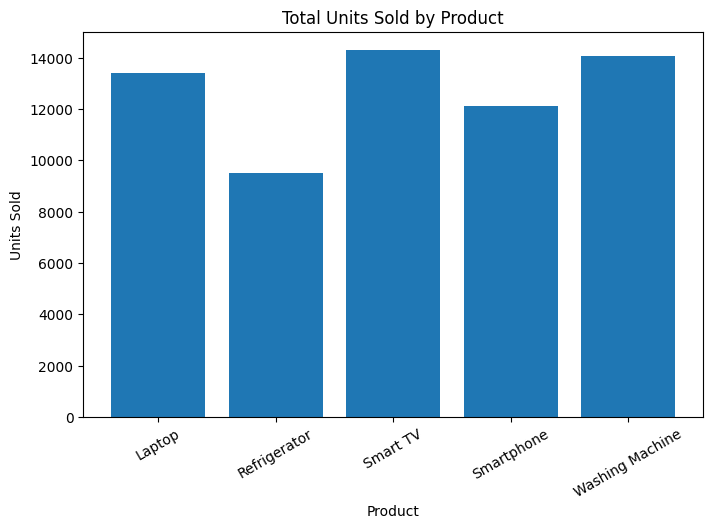

In [11]:
plt.figure(figsize=(8,5))

plt.bar(product_sales.index, product_sales.values)

plt.title("Total Units Sold by Product")

plt.xlabel("Product")

plt.ylabel("Units Sold")

plt.xticks(rotation=30)

plt.show()

## Total Revenue by Branch

In [12]:
branch_revenue = df.groupby("Branch")["Revenue_NPR"].sum()

print(branch_revenue)

Branch
Bhaktapur      590475000
Boudha         680210000
Kalanki        676920000
Koteshwor      645080000
Lalitpur       744505000
Maharajgunj    565965000
Name: Revenue_NPR, dtype: int64


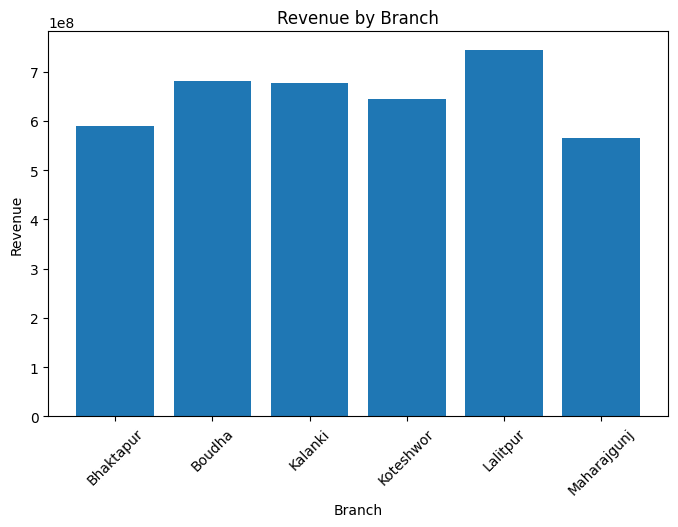

In [13]:
plt.figure(figsize=(8,5))

plt.bar(branch_revenue.index, branch_revenue.values)

plt.title("Revenue by Branch")

plt.xlabel("Branch")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

## Monthly Sales Trend

In [14]:
monthly = df.groupby("Month")["Units_Sold"].sum()

monthly

Month
Apr    5350
Aug    5357
Dec    5150
Feb    5094
Jan    5256
Jul    5220
Jun    5167
Mar    5161
May    5274
Nov    5676
Oct    5517
Sep    5148
Name: Units_Sold, dtype: int64

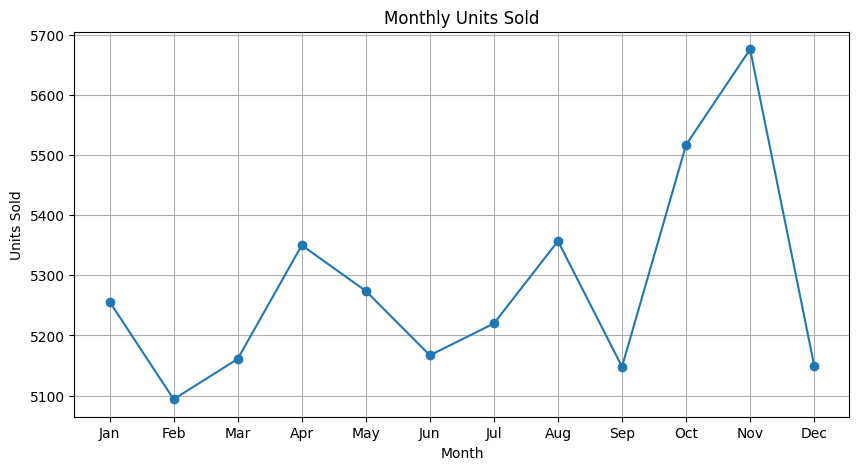

In [15]:
month_order = [
    "Jan","Feb","Mar","Apr",
    "May","Jun","Jul","Aug",
    "Sep","Oct","Nov","Dec"
]

monthly = monthly.reindex(month_order)

plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.title("Monthly Units Sold")

plt.xlabel("Month")

plt.ylabel("Units Sold")

plt.grid()

plt.show()

## Create OLAP Data Cube
Dimensions: Branch, Product
Measure: Units Sold

In [16]:
cube = pd.pivot_table(
    df,
    values="Units_Sold",
    index="Branch",
    columns="Product",
    aggfunc="sum",
    fill_value=0
)

cube

Product,Laptop,Refrigerator,Smart TV,Smartphone,Washing Machine
Branch,,,,,
Bhaktapur,3046,1094,1556,1595,1719
Boudha,2238,1292,2718,2196,2683
Kalanki,1786,1937,2853,1850,2710
Koteshwor,2885,1341,1612,2498,2094
Lalitpur,2169,2628,2596,2917,2156
Maharajgunj,1276,1198,2954,1079,2694


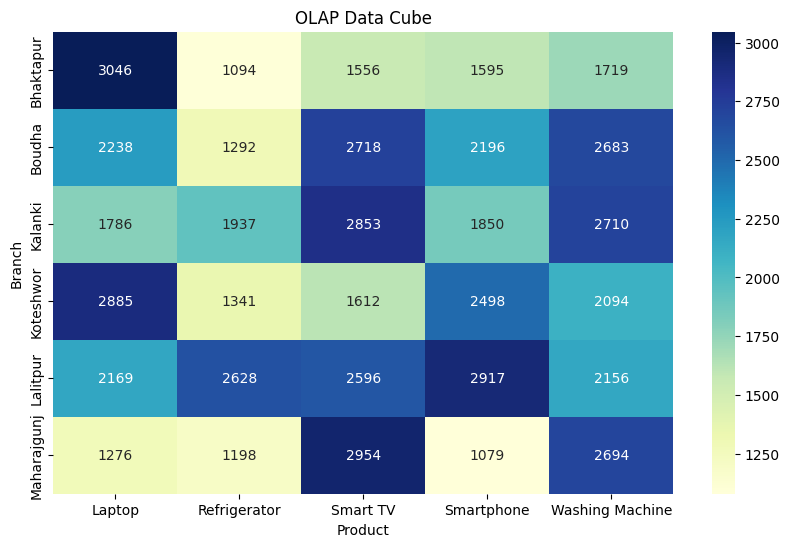

In [17]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cube,
    annot=True,
    cmap="YlGnBu",
    fmt=".0f"
)

plt.title("OLAP Data Cube")

plt.show()

## Roll-Up Operation

In [18]:
rollup = df.groupby(
    ["Branch", "Product"]
)["Units_Sold"].sum()

rollup

Branch       Product        
Bhaktapur    Laptop             3046
             Refrigerator       1094
             Smart TV           1556
             Smartphone         1595
             Washing Machine    1719
Boudha       Laptop             2238
             Refrigerator       1292
             Smart TV           2718
             Smartphone         2196
             Washing Machine    2683
Kalanki      Laptop             1786
             Refrigerator       1937
             Smart TV           2853
             Smartphone         1850
             Washing Machine    2710
Koteshwor    Laptop             2885
             Refrigerator       1341
             Smart TV           1612
             Smartphone         2498
             Washing Machine    2094
Lalitpur     Laptop             2169
             Refrigerator       2628
             Smart TV           2596
             Smartphone         2917
             Washing Machine    2156
Maharajgunj  Laptop             1276
         

In [19]:
rollup_table = rollup.unstack()

rollup_table

Product,Laptop,Refrigerator,Smart TV,Smartphone,Washing Machine
Branch,,,,,
Bhaktapur,3046,1094,1556,1595,1719
Boudha,2238,1292,2718,2196,2683
Kalanki,1786,1937,2853,1850,2710
Koteshwor,2885,1341,1612,2498,2094
Lalitpur,2169,2628,2596,2917,2156
Maharajgunj,1276,1198,2954,1079,2694


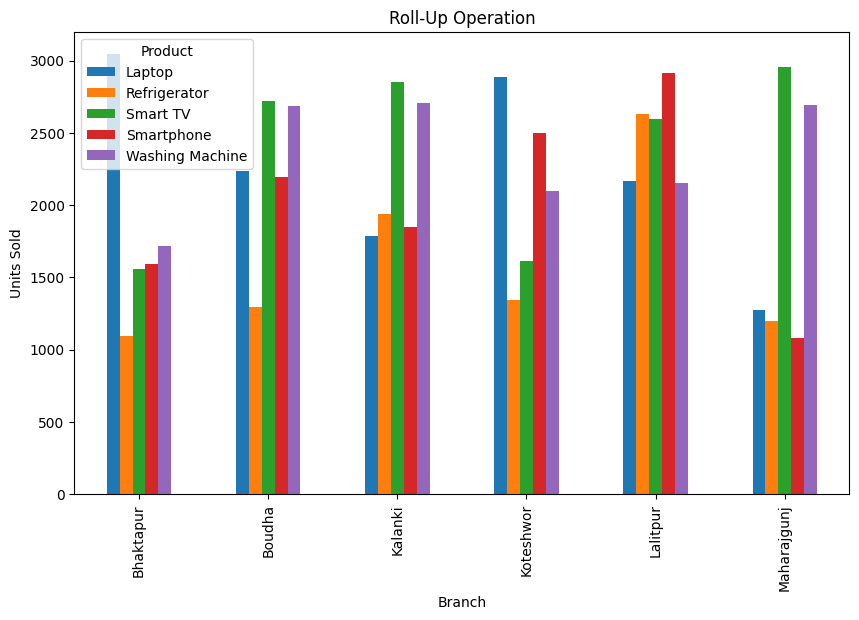

In [20]:
rollup_table.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Roll-Up Operation")

plt.ylabel("Units Sold")

plt.show()

## Drill-Down Operation
View Branch × Month details.

In [21]:
drill = pd.pivot_table(
    df,
    values="Units_Sold",
    index="Branch",
    columns="Month",
    aggfunc="sum",
    fill_value=0
)

drill

Month,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Mar,May,Nov,Oct,Sep
Branch,,,,,,,,,,,,
Bhaktapur,745,766,766,707,722,755,722,759,798,828,757,685
Boudha,987,868,892,959,890,921,901,921,900,1010,948,930
Kalanki,959,994,906,871,951,938,942,834,907,924,1038,872
Koteshwor,819,881,855,861,888,876,781,910,835,969,927,828
Lalitpur,1069,1107,994,955,1020,1003,1031,992,1070,1077,1080,1068
Maharajgunj,771,741,737,741,785,727,790,745,764,868,767,765


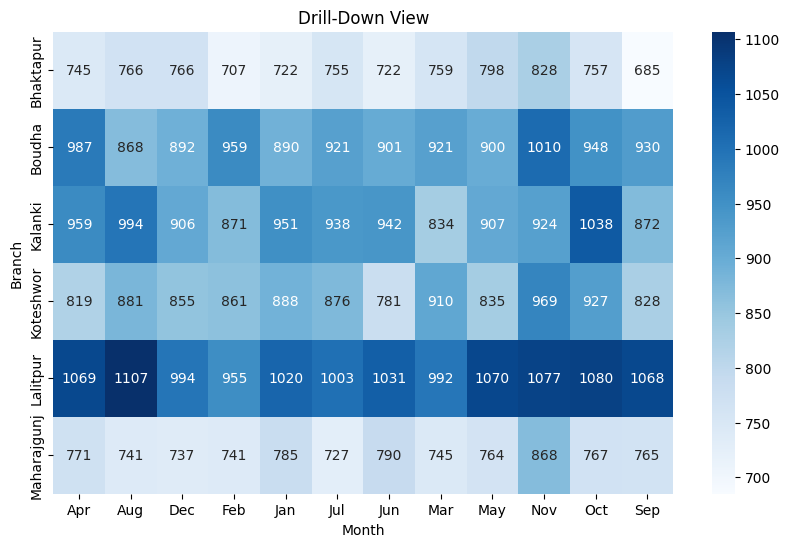

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(
    drill,
    annot=True,
    cmap="Blues",
    fmt=".0f"
)

plt.title("Drill-Down View")

plt.show()

## Slice Operation
Take only January.

In [23]:
jan = df[df["Month"] == "Jan"]

jan

,Year,Month,Branch,Product,Units_Sold,Unit_Price_NPR,Revenue_NPR
0,2025,Jan,Koteshwor,Laptop,220,90000,19800000
12,2025,Jan,Koteshwor,Smartphone,194,35000,6790000
24,2025,Jan,Koteshwor,Smart TV,145,70000,10150000
36,2025,Jan,Koteshwor,Refrigerator,134,60000,8040000
48,2025,Jan,Koteshwor,Washing Machine,195,50000,9750000
60,2025,Jan,Maharajgunj,Laptop,105,90000,9450000
72,2025,Jan,Maharajgunj,Smartphone,103,35000,3605000
84,2025,Jan,Maharajgunj,Smart TV,265,70000,18550000
96,2025,Jan,Maharajgunj,Refrigerator,106,60000,6360000
108,2025,Jan,Maharajgunj,Washing Machine,206,50000,10300000


In [24]:
slice_table = pd.pivot_table(
    jan,
    values="Units_Sold",
    index="Branch",
    columns="Product",
    aggfunc="sum",
    fill_value=0
)

slice_table

Product,Laptop,Refrigerator,Smart TV,Smartphone,Washing Machine
Branch,,,,,
Bhaktapur,248,79,111,146,138
Boudha,169,87,226,207,201
Kalanki,167,163,217,149,255
Koteshwor,220,134,145,194,195
Lalitpur,166,196,215,258,185
Maharajgunj,105,106,265,103,206


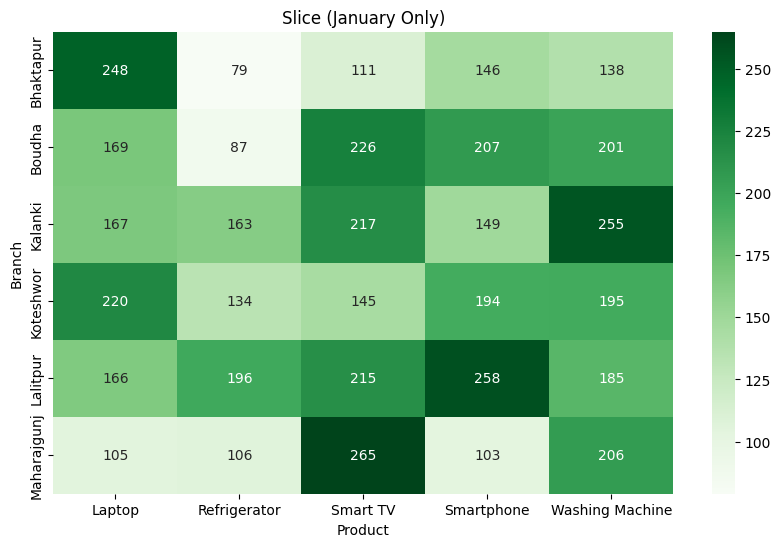

In [25]:
plt.figure(figsize=(10,6))

sns.heatmap(
    slice_table,
    annot=True,
    cmap="Greens",
    fmt=".0f"
)

plt.title("Slice (January Only)")

plt.show()

## Dice Operation
Select:

Jan
Feb
Laptop
Koteshwor
Kalanki

In [26]:
dice = df[
    (df["Month"].isin(["Jan", "Feb"])) &
    (df["Product"] == "Laptop") &
    (df["Branch"].isin([
        "Koteshwor",
        "Kalanki"
    ]))
]

dice

,Year,Month,Branch,Product,Units_Sold,Unit_Price_NPR,Revenue_NPR
0,2025,Jan,Koteshwor,Laptop,220,90000,19800000
1,2025,Feb,Koteshwor,Laptop,214,90000,19260000
180,2025,Jan,Kalanki,Laptop,167,90000,15030000
181,2025,Feb,Kalanki,Laptop,159,90000,14310000


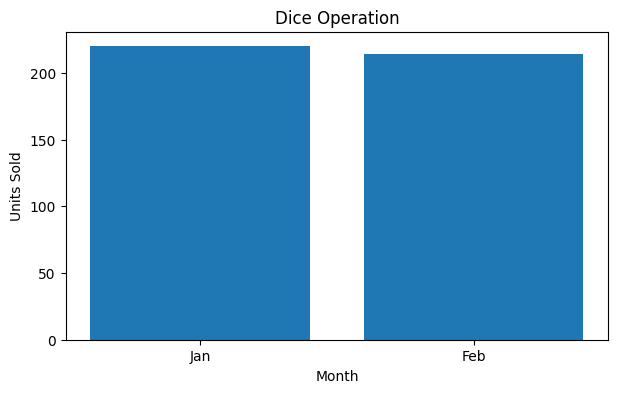

In [27]:
plt.figure(figsize=(7,4))

plt.bar(
    dice["Month"],
    dice["Units_Sold"]
)

plt.title("Dice Operation")

plt.xlabel("Month")

plt.ylabel("Units Sold")

plt.show()

## Pivot Operation

In [28]:
pivot = pd.pivot_table(
    df,
    values="Units_Sold",
    index="Product",
    columns="Branch",
    aggfunc="sum",
    fill_value=0
)

pivot

Branch,Bhaktapur,Boudha,Kalanki,Koteshwor,Lalitpur,Maharajgunj
Product,,,,,,
Laptop,3046,2238,1786,2885,2169,1276
Refrigerator,1094,1292,1937,1341,2628,1198
Smart TV,1556,2718,2853,1612,2596,2954
Smartphone,1595,2196,1850,2498,2917,1079
Washing Machine,1719,2683,2710,2094,2156,2694


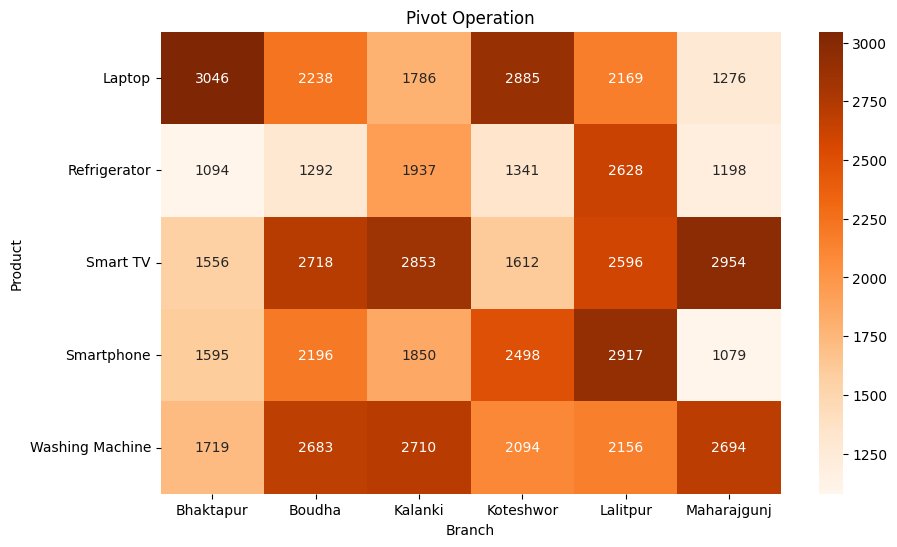

In [29]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="Oranges",
    fmt=".0f"
)

plt.title("Pivot Operation")

plt.show()